<a href="https://colab.research.google.com/github/yxngles13/WIDS_Datathon_2026/blob/main/WIDS_Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!kaggle competitions download -c WiDSWorldWide_GlobalDathon26

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Datasets

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)

(221, 37)
(95, 35)


In [ ]:
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,0.000000,0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,0.000000,0.000000,21,5,7,44.990274,0


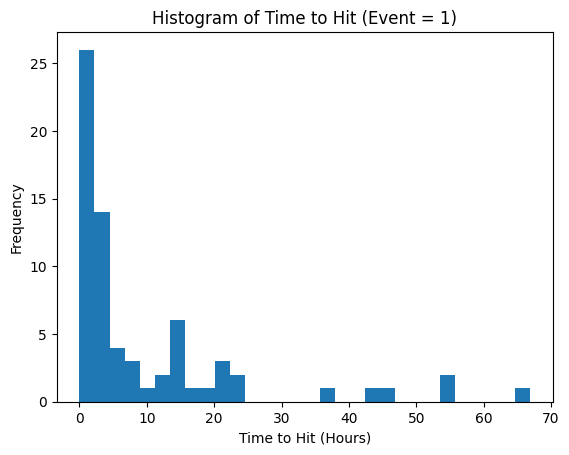

In [ ]:
# EDA
# Histogram of time_to_hit_hours (for event = 1)
event_times = train[train["event"] == 1]["time_to_hit_hours"]

plt.figure()
plt.hist(event_times, bins=30)
plt.xlabel("Time to Hit (Hours)")
plt.ylabel("Frequency")
plt.title("Histogram of Time to Hit (Event = 1)")
plt.show()


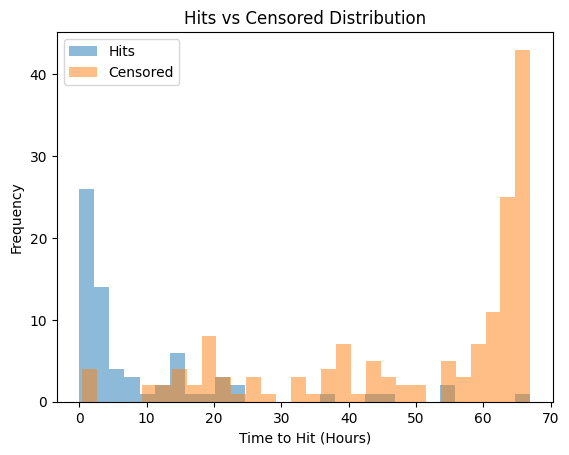

In [ ]:
# Hits vs Censored Distribution
hits = train[train["event"] == 1]["time_to_hit_hours"]
censored = train[train["event"] == 0]["time_to_hit_hours"]

plt.figure()

plt.hist(hits, bins=30, alpha=0.5, label="Hits")
plt.hist(censored, bins=30, alpha=0.5, label="Censored")

plt.xlabel("Time to Hit (Hours)")
plt.ylabel("Frequency")
plt.title("Hits vs Censored Distribution")
plt.legend()

plt.show()

In [ ]:
# Checking Class Imbalance
train["event"].value_counts()

,count
event,
0,152
1,69


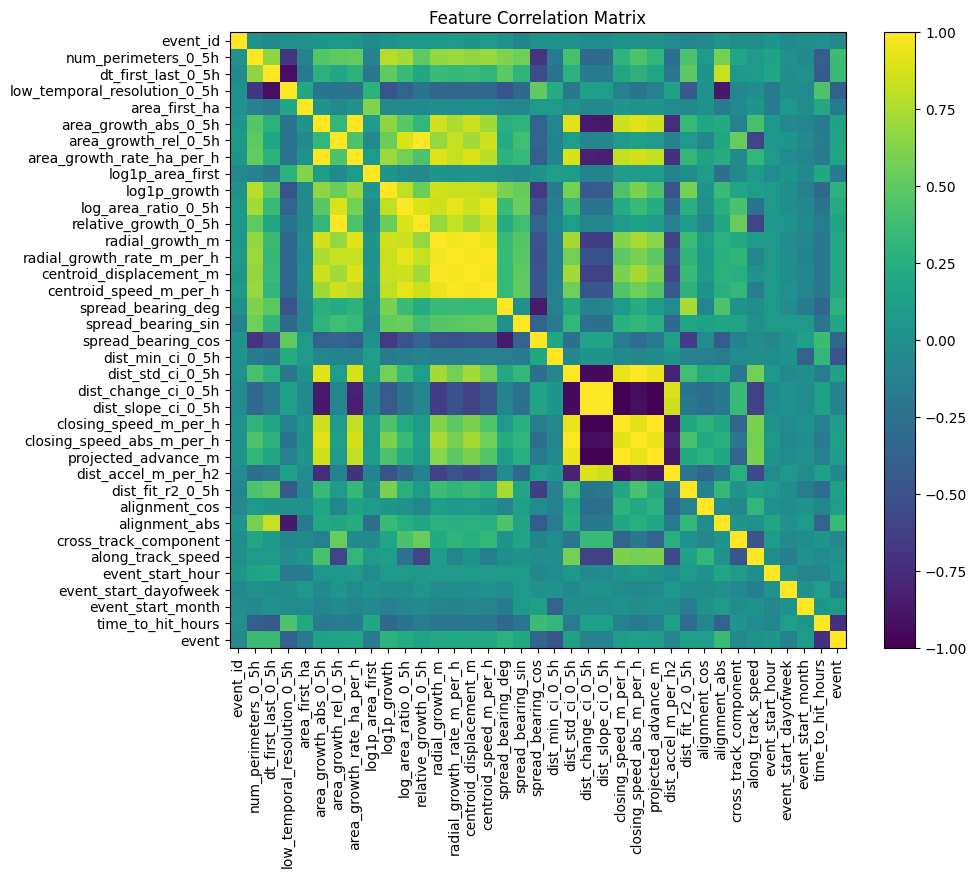

In [ ]:
# Feature Relationships
# Correlation Matrix
train_numeric = train.select_dtypes(include=["int64", "float64"])
corr_matrix = train_numeric.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
#drop redundant features
features_to_keep = [
    'area_first_ha',
    'area_growth_rate_ha_per_h',   # drop the 6 other growth variants
    'radial_growth_rate_m_per_h',
    'centroid_speed_m_per_h',
    'spread_bearing_sin', 'spread_bearing_cos',
    'dist_min_ci_0_5h',            # most important distance feature
    'closing_speed_m_per_h',       # drop the redundant closing variants
    'dist_fit_r2_0_5h',
    'alignment_cos',               # drop alignment_abs (same info)
    'along_track_speed',
    'event_start_hour',
    'event_start_month',
    'low_temporal_resolution_0_5h',
    'num_perimeters_0_5h'
]

In [ ]:
!pip install scikit-survival

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
import pandas as pd
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 18.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

features = [col for col in train.columns if col not in ['event_id', 'event', 'time_to_hit_hours']]

X_train = train[features]
X_test = test[features]


In [ ]:
y_train = Surv.from_dataframe('event', 'time_to_hit_hours', train)


In [ ]:
rsf = RandomSurvivalForest(
    n_estimators = 300,
    min_samples_leaf=20,
    max_features=0.5,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)
rsf.fit(X_train, y_train)

,n_estimators,300
,max_depth,4
,min_samples_split,6
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [ ]:
# horizons = [12,24,48,72]

# surv_funcs = rsf.predict_survival_function(X_test)

# rows = []
# for i, fn in enumerate(surv_funcs):
#   probs = [1 - fn(t) for t in horizons]
#   rows.append(probs)

# preds = pd.DataFrame(rows, columns=horizons, index=test['event_id'])
# preds.to_csv('submission.csv')

In [ ]:
horizons = [12, 24, 48, 72]

surv_funcs = rsf.predict_survival_function(X_test)

def safe_eval_surv(fn, t):
    if t <= fn.x[0]:
        return fn.y[0]
    if t >= fn.x[-1]:
        return fn.y[-1]
    return fn(t)

rows = []
for fn in surv_funcs:
    probs = [1 - safe_eval_surv(fn, t) for t in horizons]
    rows.append(probs)

preds = pd.DataFrame(rows, columns=horizons, index=test["event_id"])
preds.to_csv("submission.csv", index=True)

In [ ]:
submission = preds.reset_index()

submission = submission.rename(columns={
    12: 'prob_12h',
    24: 'prob_24h',
    48: 'prob_48h',
    72: 'prob_72h'
})

submission.to_csv('submission.csv', index=False)

In [ ]:
from sksurv.metrics import concordance_index_censored

# Predict risk scores for the training data
risk_scores_train = rsf.predict(X_train)

# Calculate the Concordance Index (C-index)
c_index = concordance_index_censored(y_train['event'], y_train['time_to_hit_hours'], risk_scores_train)

print(f"C-index on training data: {c_index[0]:.4f}")

C-index on training data: 0.9466


In [ ]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

c_indices_folds = []

for train_idx, val_idx in skf.split(X_train, y_train['event']):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Fit the model on the training data for the current fold
    rsf.fit(X_train_fold, y_train_fold)

    # Predict risk scores on the validation set for the current fold
    risk_scores_val = rsf.predict(X_val_fold)

    # Calculate C-index for the current fold
    c_index_fold = concordance_index_censored(y_val_fold['event'], y_val_fold['time_to_hit_hours'], risk_scores_val)[0]
    c_indices_folds.append(c_index_fold)

print(f"Mean C-index from {n_splits}-fold cross-validation: {np.mean(c_indices_folds):.4f} +/- {np.std(c_indices_folds):.4f}")

Mean C-index from 5-fold cross-validation: 0.9342 +/- 0.0163


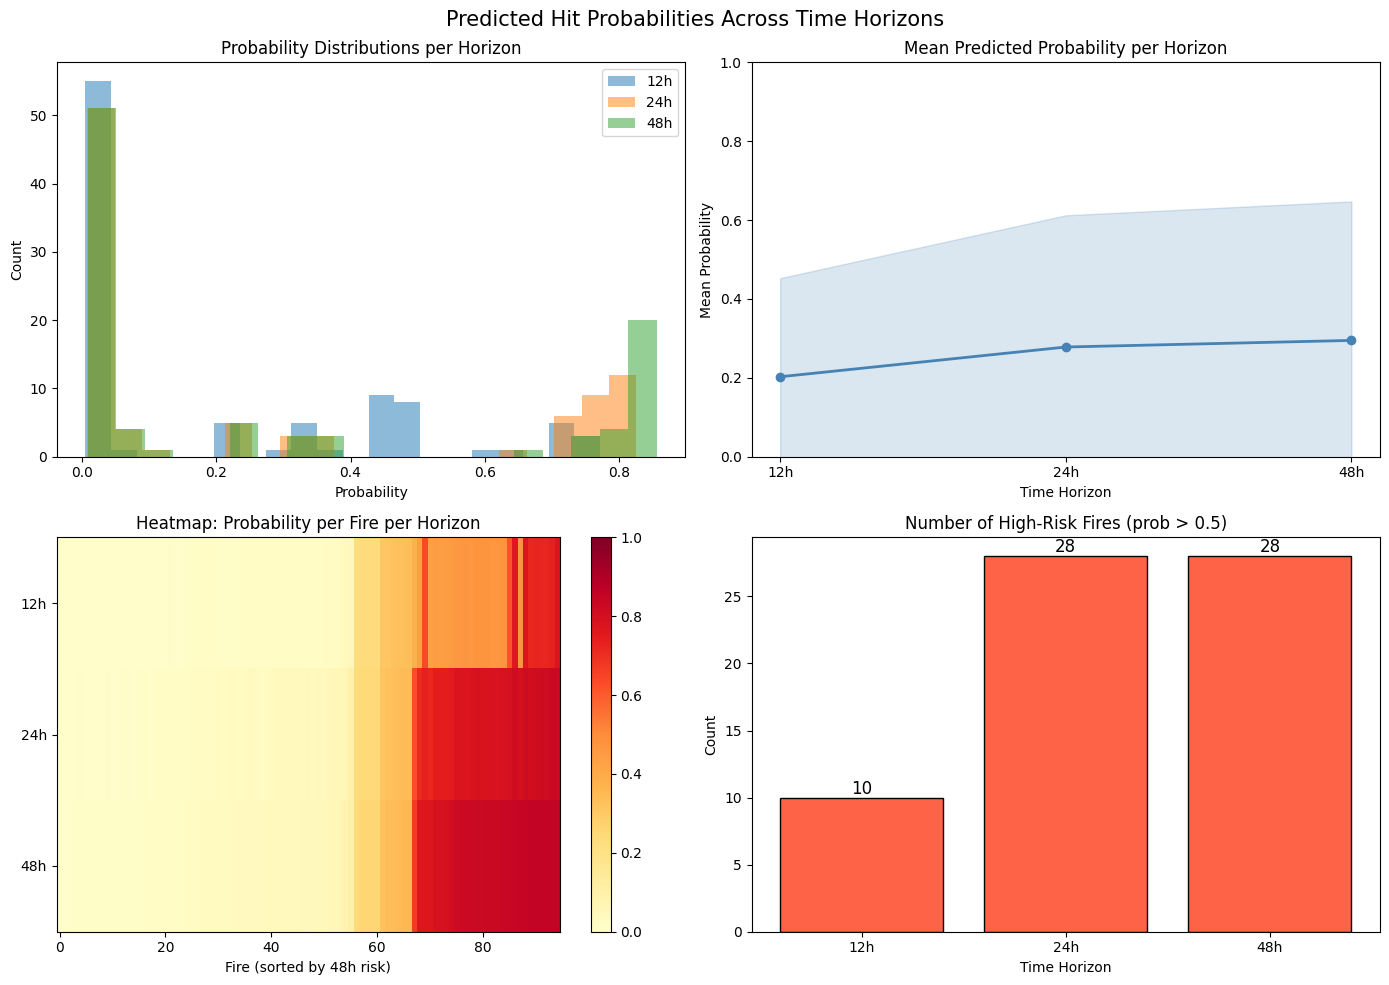

In [ ]:
horizons = ['12h', '24h', '48h']
prob_cols = ['prob_12h', 'prob_24h', 'prob_48h']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Predicted Hit Probabilities Across Time Horizons', fontsize=15)

# 1. Distribution of probabilities per horizon
ax = axes[0, 0]
for col, h in zip(prob_cols, horizons):
    ax.hist(submission[col], bins=20, alpha=0.5, label=h)
ax.set_title('Probability Distributions per Horizon')
ax.set_xlabel('Probability')
ax.set_ylabel('Count')
ax.legend()

# 2. Mean probability per horizon (how urgency grows over time)
ax = axes[0, 1]
means = [submission[col].mean() for col in prob_cols]
stds  = [submission[col].std() for col in prob_cols]
ax.plot(horizons, means, marker='o', color='steelblue', linewidth=2)
ax.fill_between(horizons,
                [m-s for m,s in zip(means,stds)],
                [m+s for m,s in zip(means,stds)],
                alpha=0.2, color='steelblue')
ax.set_title('Mean Predicted Probability per Horizon')
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Mean Probability')
ax.set_ylim(0, 1)

# 3. Heatmap of probabilities per fire (sorted by 48h risk - updated for available horizons)
ax = axes[1, 0]
sorted_df = submission.sort_values('prob_48h')[prob_cols].values
im = ax.imshow(sorted_df.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(len(horizons)))
ax.set_yticklabels(horizons)
ax.set_xlabel('Fire (sorted by 48h risk)')
ax.set_title('Heatmap: Probability per Fire per Horizon')
plt.colorbar(im, ax=ax)

# 4. High risk fires (prob_48h > 0.5 - updated for available horizons)
ax = axes[1, 1]
risk_counts = [(submission[col] > 0.5).sum() for col in prob_cols]
ax.bar(horizons, risk_counts, color='tomato', edgecolor='black')
ax.set_title('Number of High-Risk Fires (prob > 0.5)')
ax.set_xlabel('Time Horizon')
ax.set_ylabel('Count')
for i, v in enumerate(risk_counts):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('probability_visualizations.png', dpi=150)
plt.show()